## Run initially to download data otherwise ignore


In [1]:
#pip install kagglehub

In [2]:
'''
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tunguz/superconductivty-data-data-set")

print("Path to dataset files:", path)
'''

'\nimport kagglehub\n\n# Download latest version\npath = kagglehub.dataset_download("tunguz/superconductivty-data-data-set")\n\nprint("Path to dataset files:", path)\n'

## Main code

In [3]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures


# maximize display of dataframe columns
pd.set_option('display.max_columns', None)

# maximize display of dataframe rows
pd.set_option('display.max_rows', None)

First I am simply opening the data file and examining its contents

In [4]:
file = './train.csv' # path to the data file

with open(file, 'r') as f:
    reader = csv.reader(f)
    labels = next(reader)
    data = [row for row in reader]

# Convert data to DataFrame for easier handling
df = pd.DataFrame(data, columns=labels)

In [5]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,wtd_std_atomic_mass,mean_fie,wtd_mean_fie,gmean_fie,wtd_gmean_fie,entropy_fie,wtd_entropy_fie,range_fie,wtd_range_fie,std_fie,wtd_std_fie,mean_atomic_radius,wtd_mean_atomic_radius,gmean_atomic_radius,wtd_gmean_atomic_radius,entropy_atomic_radius,wtd_entropy_atomic_radius,range_atomic_radius,wtd_range_atomic_radius,std_atomic_radius,wtd_std_atomic_radius,mean_Density,wtd_mean_Density,gmean_Density,wtd_gmean_Density,entropy_Density,wtd_entropy_Density,range_Density,wtd_range_Density,std_Density,wtd_std_Density,mean_ElectronAffinity,wtd_mean_ElectronAffinity,gmean_ElectronAffinity,wtd_gmean_ElectronAffinity,entropy_ElectronAffinity,wtd_entropy_ElectronAffinity,range_ElectronAffinity,wtd_range_ElectronAffinity,std_ElectronAffinity,wtd_std_ElectronAffinity,mean_FusionHeat,wtd_mean_FusionHeat,gmean_FusionHeat,wtd_gmean_FusionHeat,entropy_FusionHeat,wtd_entropy_FusionHeat,range_FusionHeat,wtd_range_FusionHeat,std_FusionHeat,wtd_std_FusionHeat,mean_ThermalConductivity,wtd_mean_ThermalConductivity,gmean_ThermalConductivity,wtd_gmean_ThermalConductivity,entropy_ThermalConductivity,wtd_entropy_ThermalConductivity,range_ThermalConductivity,wtd_range_ThermalConductivity,std_ThermalConductivity,wtd_std_ThermalConductivity,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.9444675,57.8626922857143,66.3615924315719,36.1166119053847,1.1817952393305,1.06239554519617,122.90607,31.7949208571429,51.9688277861034,53.6225345301219,775.425,1010.26857142857,718.15289995213,938.016780052204,1.30596703599158,0.791487788469155,810.6,735.985714285714,323.811807806633,355.562966713294,160.25,105.514285714286,136.126003095455,84.528422716633,1.25924397214289,1.20703998701461,205,42.9142857142857,75.2375404967494,69.2355694829807,4654.35725,2961.50228571429,724.953210852388,53.5438109235142,1.03312880053102,0.814598190091683,8958.571,1579.58342857143,3306.1628967555,3572.59662370838,81.8375,111.727142857143,60.1231785550982,99.4146820543113,1.15968659338134,0.787381690763223,127.05,80.9871428571429,51.4337118896741,42.55839575195,6.9055,3.84685714285714,3.47947484936327,1.04098598567486,1.08857534188499,0.994998193254128,12.878,1.74457142857143,4.59906411675245,4.66691955388659,107.756645,61.0151885714286,7.06248773046785,0.62197948704754,0.308147989812345,0.262848266362233,399.97342,57.1276685714286,168.854243757651,138.51716251123,2.25,2.25714285714286,2.21336383940064,2.21978342968743,1.36892236074022,1.0662210317362,1,1.08571428571429,0.433012701892219,0.43705881545081,29
1,5,92.729214,58.5184161428571,73.1327872225065,36.3966020291995,1.44930919335685,1.05775512271911,122.90607,36.161939,47.0946331703134,53.9798696513451,766.44,1010.61285714286,720.605510513725,938.745412527433,1.54414454326973,0.807078214938731,810.6,743.164285714286,290.183029138508,354.963511171592,161.2,104.971428571429,141.465214777999,84.3701669575628,1.50832754035259,1.2041147982326,205,50.5714285714286,67.321319060161,68.0088169554027,5821.4858,3021.01657142857,1237.09508033858,54.0957182556368,1.31444218462105,0.914802177066343,10488.571,1667.38342857143,3767.40317577062,3632.64918471043,90.89,112.316428571429,69.8333146094209,101.166397739874,1.42799655342352,0.83866646563365,127.05,81.2078571428572,49.4381674417651,41.6676207979191,7.7844,3.79685714285714,4.40379049753476,1.03525111582814,1.37497728009085,1.07309384625263,12.878,1.59571428571429,4.47336265464807,4.60300005985449,172.205316,61.3723314285714,16.0642278788044,0.619734632330547,0.847404163195705,0.567706107876637,429.97342,51.4133828571429,198.554600255545,139.630922368904,2,2.25714285714286,1.8881750225898,2.21067940870655,1.55711309805765,1.04722136819323,2,1.12857142857143,0.632455532033676

Here I filter the target values (temperature) out of the data creating two arrays, one for the features, and one for the targets

In [6]:
target = 'critical_temp'
features = [col for col in df.columns if col != target]

X = df[features].astype(float) # Features
y = df[target].astype(float) # Targets

Next, I split the data into training and testing groups with an 80/20 ratio, and scale the data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split data into training and testing sets

scaler = StandardScaler() # Standardize features by removing the mean and scaling to unit variance

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
X_train.shape  # there are 81 initial features

(17010, 81)

With this initial data of 81 featues, I will perform a hyperparameter grid search to find the most optimal initial settings.

In [9]:
# grid search for hyperparameter tuning

param_grid = {'alpha': [0.005, 0.01, 0.05, 0.1, 0.5], 'l1_ratio': [0.25, 0.5, 0.75, 0.9, 1]}

elastic_net = ElasticNet(max_iter=20000, random_state=42)

grid_search = GridSearchCV(estimator=elastic_net, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_alpha = grid_search.best_params_['alpha']
best_l1_ratio = grid_search.best_params_['l1_ratio']
print(f"Best alpha: {best_alpha}")
print(f"Best l1_ratio: {best_l1_ratio}")

Best alpha: 0.005
Best l1_ratio: 1


In [10]:
# Look at grid search results
results = pd.DataFrame(grid_search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
print(results[['param_alpha', 'param_l1_ratio', 'mean_test_score']])

    param_alpha  param_l1_ratio  mean_test_score
4         0.005            1.00         0.733246
9         0.010            1.00         0.731792
3         0.005            0.90         0.731448
2         0.005            0.75         0.729686
8         0.010            0.90         0.728977
1         0.005            0.50         0.727120
7         0.010            0.75         0.725927
0         0.005            0.25         0.724979
6         0.010            0.50         0.722073
5         0.010            0.25         0.719236
14        0.050            1.00         0.718758
13        0.050            0.90         0.713766
12        0.050            0.75         0.709137
19        0.100            1.00         0.708856
11        0.050            0.50         0.704157
18        0.100            0.90         0.703460
10        0.050            0.25         0.700716
17        0.100            0.75         0.698695
16        0.100            0.50         0.693772
15        0.100     

Once the best hyperparameters are found, train the Elestic Net model

In [11]:
#  Train the model with the best hyperparameters
model = ElasticNet(max_iter=20000, random_state=42)

model.set_params(alpha=best_alpha, l1_ratio=best_l1_ratio)
model.fit(X_train_scaled, y_train)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring='r2', return_train_score=True)

train_scores = cv_results['train_score']
test_scores = cv_results['test_score']

train_uncertainty = np.std(train_scores)
test_uncertainty = np.std(test_scores)

print(f"Mean Train R^2: {np.mean(train_scores):.4f} ± {train_uncertainty:.4f}")
print(f"Mean Test R^2: {np.mean(test_scores):.4f} ± {test_uncertainty:.4f}")

Mean Train R^2: 0.7360 ± 0.0015
Mean Test R^2: 0.7333 ± 0.0064


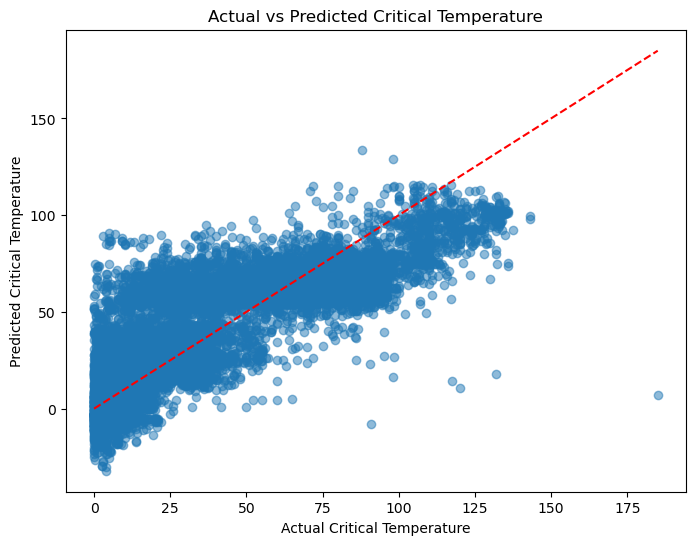

In [12]:
ypred = cross_val_predict(model, X_train_scaled, y_train, cv=cv)

# Plot actual vs predicted critical temperatures
plt.figure(figsize=(8, 6))
plt.scatter(y_train, ypred, alpha=0.5) 
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Critical Temperature')
plt.ylabel('Predicted Critical Temperature')
plt.title('Actual vs Predicted Critical Temperature')
plt.show()

The initial results give the following results:

Mean Train $R^2$: $0.7360 \pm 0.0015$

Mean Test $R^2$: $0.7333 \pm 0.0064$

This shows some intrinsic correlation, but not a strong one. Let's see if we can make it better by finding top 15 most important features and engineering new features out of these.

In [13]:
# Get absolute coefficient magnitudes
important = pd.Series(model.coef_, index=X.columns)

# Sort by absolute value (descending order)
important_sorted = important.abs().sort_values(ascending=False)

print("Number of selected features:", len(important))

for i in range(len(important_sorted)):
    print(f"{i + 1}  {important_sorted.index[i]}: {important_sorted[i]}")

Number of selected features: 81
1  wtd_gmean_atomic_radius: 55.42490983289143
2  wtd_mean_atomic_radius: 55.22195953796562
3  std_ElectronAffinity: 27.200940397996003
4  wtd_mean_ThermalConductivity: 24.02265284495944
5  wtd_entropy_Valence: 23.568139431159654
6  range_ElectronAffinity: 22.039894097045035
7  entropy_Valence: 20.94466321167164
8  range_fie: 18.879484314851428
9  wtd_gmean_ElectronAffinity: 18.40387903090517
10  wtd_mean_ElectronAffinity: 16.988400254691687
11  std_fie: 16.115846048902082
12  wtd_mean_FusionHeat: 16.0525322472022
13  std_atomic_radius: 15.974986152430942
14  wtd_mean_atomic_mass: 15.847714002326716
15  range_atomic_radius: 15.013726336274056
16  mean_atomic_mass: 14.73465276808244
17  wtd_entropy_atomic_radius: 14.674301606946697
18  std_ThermalConductivity: 14.056397306583925
19  wtd_gmean_ThermalConductivity: 13.420491721219545
20  wtd_entropy_fie: 13.271752474436884
21  range_ThermalConductivity: 12.639408437409717
22  mean_Density: 12.282688063220775

C:\Users\Ben\AppData\Local\Temp\ipykernel_32804\3678223263.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{i + 1}  {important_sorted.index[i]}: {important_sorted[i]}")


In [14]:
cropped_idx = important.index[important.abs() != 0.0].tolist()
print("Number of features after cropping:", len(cropped_idx))

# Create a new DataFrame with only the selected features
cropped_featues = X[cropped_idx] 
cropped_names = cropped_featues.columns.tolist()

X_cropped = pd.DataFrame(cropped_featues, columns=cropped_names)

Number of features after cropping: 72


In [15]:
# Create polynomial features for the top 15 most important features
top_features = important_sorted.head(15).index
X_top = X[top_features]

poly = PolynomialFeatures(2, include_bias=False)

X_poly = poly.fit_transform(X_top)
poly_feature_names  = poly.get_feature_names_out(top_features)

# Create a new DataFrame with the polynomial features
X_engineered = pd.DataFrame(X_poly, columns=poly_feature_names)

# Combine the cropped features with the polynomial features
new_features = pd.concat([X_cropped, X_engineered], axis=1)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(new_features, y, test_size=0.2, random_state=42) # Split data into training and testing sets

scaler = StandardScaler() # Standardize features by removing the mean and scaling to unit variance

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train.shape # there are 207 features after feature engineering, the 72 cropped features plus 135 polynomial features

(17010, 207)

After engineering new features, there are a total of 207 features, the 72 cropped features, plus the polynomial features.  Let's grid search again and train a new model with this new set of features.

In [18]:
# grid search for hyperparameter tuning

param_grid = {'alpha': [0.005, 0.01, 0.05, 0.1, 0.5], 'l1_ratio': [0.25, 0.5, 0.75, 0.9, 1]}

elastic_net = ElasticNet(max_iter=20000, random_state=42) # maybe set higher max_iter to ensure convergence

grid_search = GridSearchCV(estimator=elastic_net, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_alpha = grid_search.best_params_['alpha']
best_l1_ratio = grid_search.best_params_['l1_ratio']
print(f"Best alpha: {best_alpha}")
print(f"Best l1_ratio: {best_l1_ratio}")

Best alpha: 0.005
Best l1_ratio: 1


c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.505e+04, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(


In [19]:
# Look at grid search results
results = pd.DataFrame(grid_search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
print(results[['param_alpha', 'param_l1_ratio', 'mean_test_score']])

    param_alpha  param_l1_ratio  mean_test_score
4         0.005            1.00         0.772239
9         0.010            1.00         0.769050
3         0.005            0.90         0.768596
2         0.005            0.75         0.766051
8         0.010            0.90         0.764435
1         0.005            0.50         0.763556
0         0.005            0.25         0.761961
7         0.010            0.75         0.761814
6         0.010            0.50         0.759432
5         0.010            0.25         0.757620
14        0.050            1.00         0.752494
13        0.050            0.90         0.749553
12        0.050            0.75         0.746522
11        0.050            0.50         0.743510
10        0.050            0.25         0.741414
19        0.100            1.00         0.740186
18        0.100            0.90         0.737717
17        0.100            0.75         0.734921
16        0.100            0.50         0.732019
15        0.100     

In [20]:
#  Train the model with the best hyperparameters
model = ElasticNet(max_iter=20000, random_state=42)

model.set_params(alpha=best_alpha, l1_ratio=best_l1_ratio)
model.fit(X_train_scaled, y_train)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring='r2', return_train_score=True)

train_scores = cv_results['train_score']
test_scores = cv_results['test_score']

train_uncertainty = np.std(train_scores)
test_uncertainty = np.std(test_scores)

print(f"Mean Train R^2: {np.mean(train_scores):.4f} ± {train_uncertainty:.4f}")
print(f"Mean Test R^2: {np.mean(test_scores):.4f} ± {test_uncertainty:.4f}")

c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.505e+04, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.578e+03, tolerance: 1.601e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation.

Mean Train R^2: 0.7761 ± 0.0010
Mean Test R^2: 0.7723 ± 0.0044


c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.490e+04, tolerance: 1.601e+03
  model = cd_fast.enet_coordinate_descent(


c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.578e+03, tolerance: 1.601e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.284e+03, tolerance: 1.604e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation.

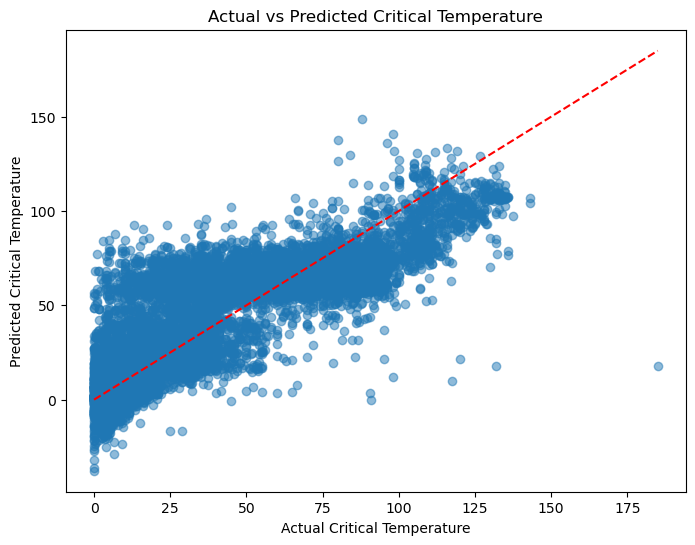

In [21]:
ypred = cross_val_predict(model, X_train_scaled, y_train, cv=cv)

plt.figure(figsize=(8, 6))
plt.scatter(y_train, ypred, alpha=0.5) 
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Critical Temperature')
plt.ylabel('Predicted Critical Temperature')
plt.title('Actual vs Predicted Critical Temperature')
plt.show()

By making these changes, the new score is:

Mean Train $R^2$: $0.7761 \pm 0.0010$

Mean Test $R^2$: $0.7723 \pm 0.0044$

This is an improvment to the original which mean I am headed in the right direction.

In [22]:
# Get absolute coefficient magnitudes
important = pd.Series(model.coef_, index=new_features.columns)

# Sort by absolute value (descending order)
important_sorted = important.abs().sort_values(ascending=False)

print("Number of selected features:", len(important))

for i in range(len(important_sorted)):
    print(f"{i + 1}  {important_sorted.index[i]}: {important_sorted[i]}")

Number of selected features: 207
1  wtd_gmean_atomic_radius wtd_mean_ThermalConductivity: 81.21619886814214
2  wtd_mean_atomic_radius wtd_mean_ThermalConductivity: 72.89160776986871
3  wtd_mean_ThermalConductivity range_atomic_radius: 43.3987862191864
4  std_ElectronAffinity range_atomic_radius: 33.773886771952824
5  wtd_gmean_ElectronAffinity range_atomic_radius: 31.771563470660958
6  wtd_mean_ThermalConductivity std_atomic_radius: 29.070298401815496
7  wtd_gmean_ElectronAffinity std_atomic_radius: 28.607594616753534
8  wtd_mean_atomic_radius std_atomic_radius: 28.232046323194965
9  wtd_gmean_atomic_radius range_atomic_radius: 27.07417162739353
10  range_ThermalConductivity: 24.70928526454115
11  range_ElectronAffinity std_atomic_radius: 21.610645784708336
12  std_ThermalConductivity: 21.495361359961453
13  wtd_mean_ThermalConductivity range_fie: 18.42831720774733
14  wtd_mean_atomic_mass: 17.258642778991216
15  wtd_entropy_fie: 12.625548750797122
16  wtd_mean_ElectronAffinity wtd_mea

C:\Users\Ben\AppData\Local\Temp\ipykernel_32804\1292869222.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{i + 1}  {important_sorted.index[i]}: {important_sorted[i]}")


In [23]:
new_cropped_idx = important.index[important.abs() != 0.0].tolist()
print("Number of features after cropping:", len(new_cropped_idx))

Number of features after cropping: 141


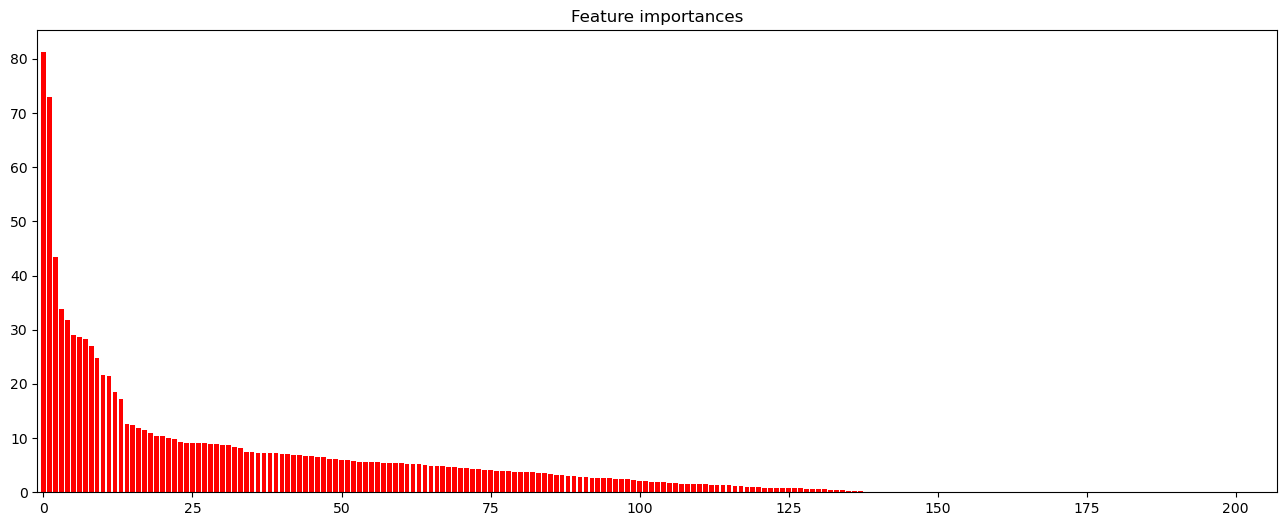

In [24]:
# Plot the feature importances 
plt.figure(figsize=(16,6))
plt.title("Feature importances")
plt.bar(range(new_features.shape[1]), important_sorted, color="r", align="center")
plt.xlim([-1, new_features.shape[1]])
plt.show()

As you can see above, of the 207 featues, 141 survived. These are the top features (some original and some engineered) that are important for our model. This is great, however 141 is a lot of features, let's visualize how important each of these are by looking at the cumylative feature importance.

C:\Users\Ben\AppData\Local\Temp\ipykernel_32804\3913946992.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = cumulative[-1]


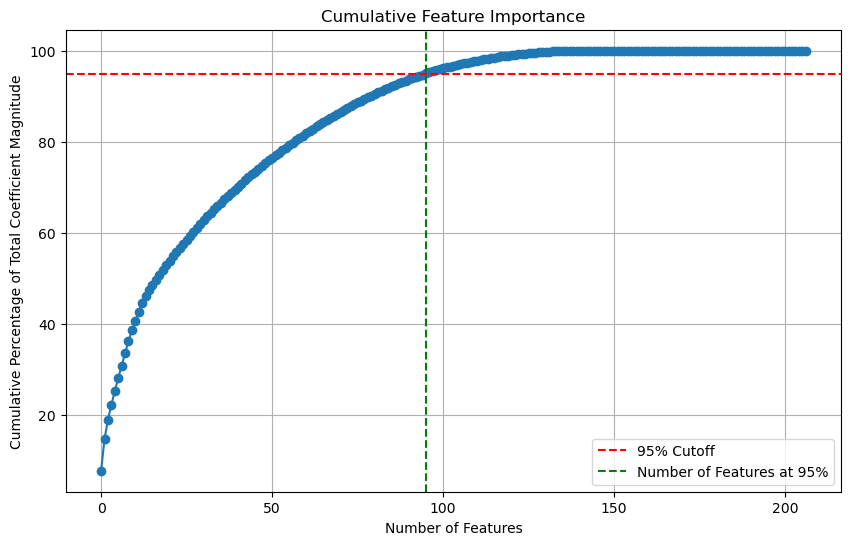

In [25]:
cumulative = np.cumsum(important_sorted)
total = cumulative[-1]
cumulative_percentage = cumulative / total * 100  # percent of total

plt.figure(figsize=(10, 6))
plt.plot(range(len(cumulative_percentage)), cumulative_percentage, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Percentage of Total Coefficient Magnitude')
plt.title('Cumulative Feature Importance')
plt.axhline(y=95, color='r', linestyle='--', label='95% Cutoff')
plt.axvline(x=np.where(cumulative_percentage >= 95)[0][0], color='g', linestyle='--', label='Number of Features at 95%')
plt.legend()
plt.grid()

In [63]:
# Cutoff at 95% cumulative importance
cutoff_idx = np.where(cumulative_percentage >= 95)[0][0]  # index where 95% is reached
num_features_to_keep = cutoff_idx + 1


important_features = important_sorted[:num_features_to_keep]

important_features.shape

(96,)

As you can see here, We can cut out data from 141 to 96 features while still retaining 95% of the importance of our features.This declutters the result slightly by getting rid of less important features while still holding validity. Let's grid serach again and train the model one more time.

In [64]:
# Train the model with the selected features

X_selected = new_features[important_features.index]

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [65]:
# grid search for hyperparameter tuning

param_grid = {'alpha': [0.005, 0.01, 0.05, 0.1, 0.5], 'l1_ratio': [0.25, 0.5, 0.75, 0.9, 1]}

elastic_net = ElasticNet(max_iter=20000, random_state=42)

grid_search = GridSearchCV(estimator=elastic_net, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_alpha = grid_search.best_params_['alpha']
best_l1_ratio = grid_search.best_params_['l1_ratio']
print(f"Best alpha: {best_alpha}")
print(f"Best l1_ratio: {best_l1_ratio}")

Best alpha: 0.005
Best l1_ratio: 1


c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.519e+03, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(


In [66]:
# Look at grid search results
results = pd.DataFrame(grid_search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
print(results[['param_alpha', 'param_l1_ratio', 'mean_test_score']])

    param_alpha  param_l1_ratio  mean_test_score
4         0.005            1.00         0.770861
9         0.010            1.00         0.768921
3         0.005            0.90         0.768365
2         0.005            0.75         0.765578
8         0.010            0.90         0.764602
1         0.005            0.50         0.762297
7         0.010            0.75         0.760674
0         0.005            0.25         0.759912
6         0.010            0.50         0.756690
5         0.010            0.25         0.753857
14        0.050            1.00         0.750454
13        0.050            0.90         0.745987
12        0.050            0.75         0.740870
19        0.100            1.00         0.736188
11        0.050            0.50         0.735020
18        0.100            0.90         0.731947
10        0.050            0.25         0.730686
17        0.100            0.75         0.726334
16        0.100            0.50         0.720054
15        0.100     

In [67]:
#  Train the model with the best hyperparameters
model = ElasticNet(max_iter=20000, random_state=42)

model.set_params(alpha=best_alpha, l1_ratio=best_l1_ratio)
model.fit(X_train_scaled, y_train)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring='r2', return_train_score=True)

train_scores = cv_results['train_score']
test_scores = cv_results['test_score']

train_uncertainty = np.std(train_scores)
test_uncertainty = np.std(test_scores)

print(f"Mean Train R^2: {np.mean(train_scores):.4f} ± {train_uncertainty:.4f}")
print(f"Mean Test R^2: {np.mean(test_scores):.4f} ± {test_uncertainty:.4f}")

c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.519e+03, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.388e+03, tolerance: 1.604e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation.

Mean Train R^2: 0.7735 ± 0.0011
Mean Test R^2: 0.7711 ± 0.0046


c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.988e+03, tolerance: 1.601e+03
  model = cd_fast.enet_coordinate_descent(


c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.388e+03, tolerance: 1.604e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.910e+03, tolerance: 1.609e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation.

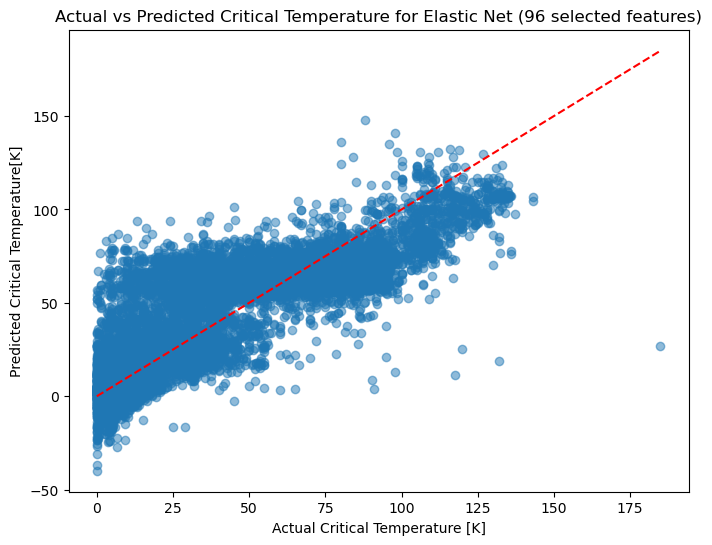

In [71]:
ypred = cross_val_predict(model, X_train_scaled, y_train, cv=cv)

plt.figure(figsize=(8, 6))
plt.scatter(y_train, ypred, alpha=0.5) 
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Critical Temperature [K]')
plt.ylabel('Predicted Critical Temperature[K]')
plt.title('Actual vs Predicted Critical Temperature for Elastic Net (96 selected features)')
plt.show()

In [69]:
print("Selected features and their importance: \n")

count = 1
count_original = 0
count_engineered = 0
for feature, importance in important_features.items():
    # if the feature was in the original feature set, print "original" next to it
    if feature in X.columns:
        print(f"{count} (original) {feature}: {importance:.4f}")
        count_original += 1
    else:
        print(f"{count} (Engineered) {feature}: {importance:.4f}")
        count_engineered += 1
    count += 1

Selected features and their importance: 

1 (Engineered) wtd_gmean_atomic_radius wtd_mean_ThermalConductivity: 81.2162
2 (Engineered) wtd_mean_atomic_radius wtd_mean_ThermalConductivity: 72.8916
3 (Engineered) wtd_mean_ThermalConductivity range_atomic_radius: 43.3988
4 (Engineered) std_ElectronAffinity range_atomic_radius: 33.7739
5 (Engineered) wtd_gmean_ElectronAffinity range_atomic_radius: 31.7716
6 (Engineered) wtd_mean_ThermalConductivity std_atomic_radius: 29.0703
7 (Engineered) wtd_gmean_ElectronAffinity std_atomic_radius: 28.6076
8 (Engineered) wtd_mean_atomic_radius std_atomic_radius: 28.2320
9 (Engineered) wtd_gmean_atomic_radius range_atomic_radius: 27.0742
10 (original) range_ThermalConductivity: 24.7093
11 (Engineered) range_ElectronAffinity std_atomic_radius: 21.6106
12 (original) std_ThermalConductivity: 21.4954
13 (Engineered) wtd_mean_ThermalConductivity range_fie: 18.4283
14 (original) wtd_mean_atomic_mass: 17.2586
15 (original) wtd_entropy_fie: 12.6255
16 (Engineered

In [70]:
print("Number of original features selected:", count_original)
print("Number of engineered features selected:", count_engineered)
print(f"Total features selected: {count_original + count_engineered}")

Number of original features selected: 41
Number of engineered features selected: 55
Total features selected: 96


Overall we ended up with 96 total features which explain 95% of the predictability of the model. Of these features, 41 of them come from the orininal dataset, while the other 55 are engineered polynomial features. When put into a model, this gives the result:

Mean Train $R^2$: $0.7735 \pm 0.0011$

Mean Test $R^2$: $0.7711 \pm 0.0046$

which still falls within the range of the feature model, so no significant data has been lost!